# MNIST-DCGAN

### Reference

つくりながら学ぶ！PyTorchによる発展ディープラーニング　5章

[DCGAN Tutorial — PyTorch Tutorials 1.11.0+cu102 documentation](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)

# import Libraries

In [16]:
import os
import random

import numpy as np

import matplotlib.pyplot as plt

import torch
import torchvision

# Configuration

In [6]:
class CFG():
    
    data_path="/Users/toutatsu/Desktop/"
    debug=True
    seed=0

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    batch_size=1#32
    epochs=30
    learning_rate=0.1
    kFold=5

    amp=False


    #高速化関連
    #https://qiita.com/sugulu_Ogawa_ISID/items/62f5f7adee083d96a587

    #GPU 遅くなるらしい↓
    torch.backends.cudnn.deterministic = True

    #イテレーションごとのnnの順伝搬および誤差関数の 計算手法がある程度一定であれば、torch.backends.cudnn.benchmark = Trueで GPU での計算が高速化
    torch.backends.cudnn.benchmark = False


def set_seed(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    #tf.random.set_seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)

print(CFG.device)
if torch.cuda.is_available():
    torch.cuda.set_device(CFG.device)
    print(torch.cuda.current_device())
    print(torch.cuda.get_device_name())

if CFG.debug:
    CFG.epochs=5

cpu


# MNIST dataset

In [45]:
MNIST={
    'train':torchvision.datasets.MNIST(
        CFG.data_path,
        train = True,
        transform = None,
        target_transform = None,
        download = True
    ),
    'test':torchvision.datasets.MNIST(
        CFG.data_path,
        train = False,
        transform = None,
        target_transform = None,
        download = True
    )
}


In [32]:
np.array(MNIST['train'][0][0]).shape

(28, 28)

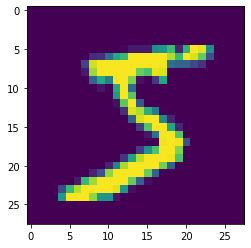

In [36]:
plt.imshow(MNIST['train'][0][0])
plt.title(MNIST['train'][0][1])

In [44]:
MNIST['train'][0]

(<PIL.Image.Image image mode=L size=28x28 at 0x112A11160>, 5)

# Generator

In [51]:
class Generator(torch.nn.Module):
    def __init__(self, z_dim=20, image_size=64):
        super(Generator, self).__init__()
        self.layer1 = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(z_dim, image_size * 8,
                               kernel_size=4, stride=1),
            torch.nn.BatchNorm2d(image_size * 8),
            torch.nn.ReLU(inplace=True))
        self.layer2 = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(image_size * 8, image_size * 4,
                               kernel_size=4, stride=2, padding=1),
            torch.nn.BatchNorm2d(image_size * 4),
            torch.nn.ReLU(inplace=True))
        self.layer3 = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(image_size * 4, image_size * 2,
                               kernel_size=4, stride=2, padding=1),
            torch.nn.BatchNorm2d(image_size * 2),
            torch.nn.ReLU(inplace=True))
        self.layer4 = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(
                image_size * 2, image_size,
                kernel_size=4, stride=2, padding=1),
                torch.nn.BatchNorm2d(image_size),
                torch.nn.ReLU(inplace=True
            )
        )
    
        self.last = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(
                image_size,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            torch.nn.Tanh()
        )
    # 注意:白黒画像なので出力チャネルは1つだけ
    def forward(self, z):
        out = self.layer1(z)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.last(out)
        return out

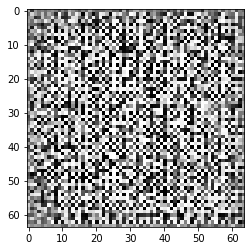

In [52]:
# 動作確認
import matplotlib.pyplot as plt 
%matplotlib inline
G = Generator(z_dim=20, image_size=64)
# 入力する乱数
input_z = torch.randn(1, 20)
# テンソルサイズを(1, 20, 1, 1)に変形
input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
# 偽画像を出力
fake_images = G(input_z)
img_transformed = fake_images[0][0].detach().numpy()
plt.imshow(img_transformed, 'gray')
plt.show()
 

# Discriminator

In [56]:
class Discriminator(torch.nn.Module):
    def __init__(self, z_dim=20, image_size=64):
        super(Discriminator, self).__init__()

        # 注意:白黒画像なので入力チャネルは1つだけ

        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(
                1,
                image_size,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            torch.nn.LeakyReLU(0.1, inplace=True)
        )
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(
                image_size,
                image_size*2,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            torch.nn.LeakyReLU(0.1, inplace=True))
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(
                image_size*2,
                image_size*4,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            torch.nn.LeakyReLU(0.1, inplace=True))
        self.layer4 = torch.nn.Sequential(
            torch.nn.Conv2d(
                image_size*4,
                image_size*8,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            torch.nn.LeakyReLU(0.1, inplace=True)
        )
        self.last = torch.nn.Conv2d(image_size*8,1,kernel_size=4,stride=1)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.last(out)
        return out

In [60]:
# 動作確認
D = Discriminator(z_dim=20, image_size=64)
# 偽画像を生成
input_z = torch.randn(1, 20)
input_z = input_z.view(input_z.size(0), input_z.size(1), 1, 1)
fake_images = G(input_z)
# 偽画像をDに入力
d_out = D(fake_images)
# 出力d_outにSigmoidをかけて0から1に変換
print(torch.nn.Sigmoid()(d_out))

tensor([[[[0.4993]]]], grad_fn=<SigmoidBackward>)


# 

In [ ]:
# Dの誤差関数のイメージ実装
# maximize log(D(x)) + log(1 - D(G(z)))
# ※ xが未定義なので動作はエラーになります # ---------------
# 正解ラベルを作成
mini_batch_size = 2
label_real = torch.full((mini_batch_size,), 1)
# 偽ラベルを作成
label_fake = torch.full((mini_batch_size,), 0)
# 誤差関数を定義
criterion = nn.BCEWithLogitsLoss(reduction='mean')
# 真の画像を判定 d_out_real = D(x)